Epoch 1/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - loss: 0.3511 - val_loss: 0.4353
Epoch 2/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - loss: 0.3220 - val_loss: 0.4406
Epoch 3/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.2988 - val_loss: 0.4488
Epoch 4/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.2834 - val_loss: 0.4451
Epoch 5/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - loss: 0.2625 - val_loss: 0.4424
Epoch 6/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - loss: 0.2490 - val_loss: 0.4432
Epoch 7/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - loss: 0.2402 - val_loss: 0.4457
Epoch 8/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.2545 - val_loss: 0.4413
Epoch 9/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.2377 - val_loss: 0.4419
Epoch 10/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.2289 - val_loss: 0.4419
Epoch 11/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.2220 - val_loss: 0.4493
Epoch 12/30
484/484 ━━━━━━━━━━

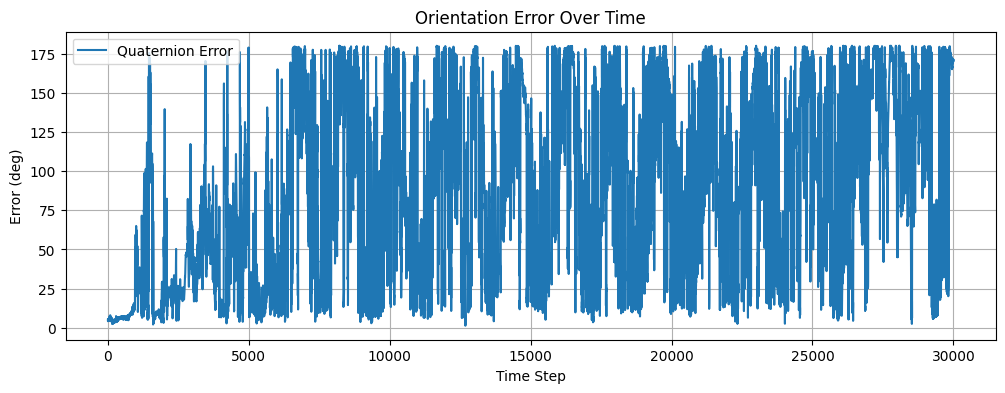

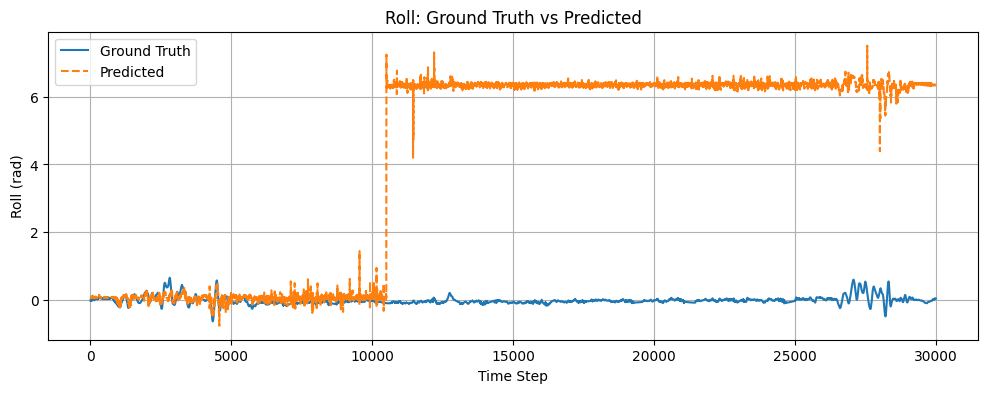

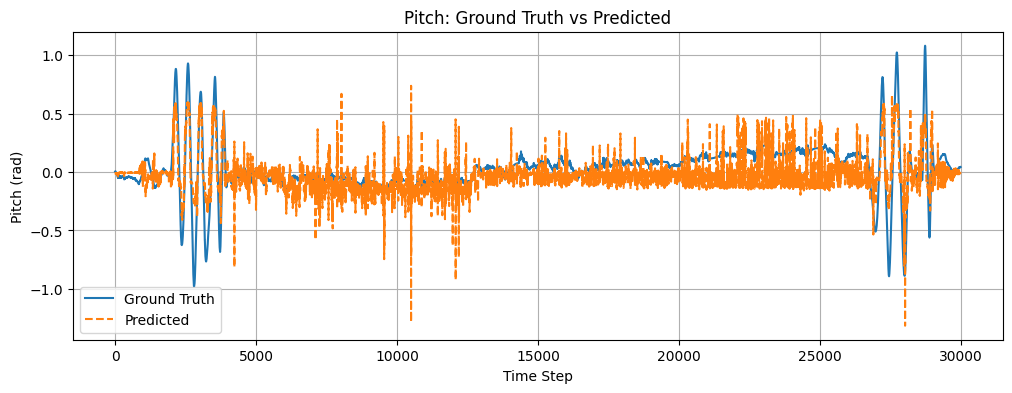

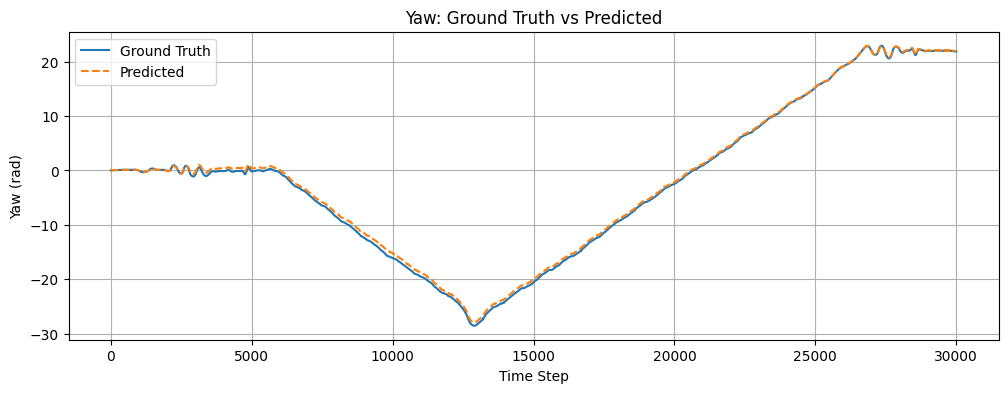

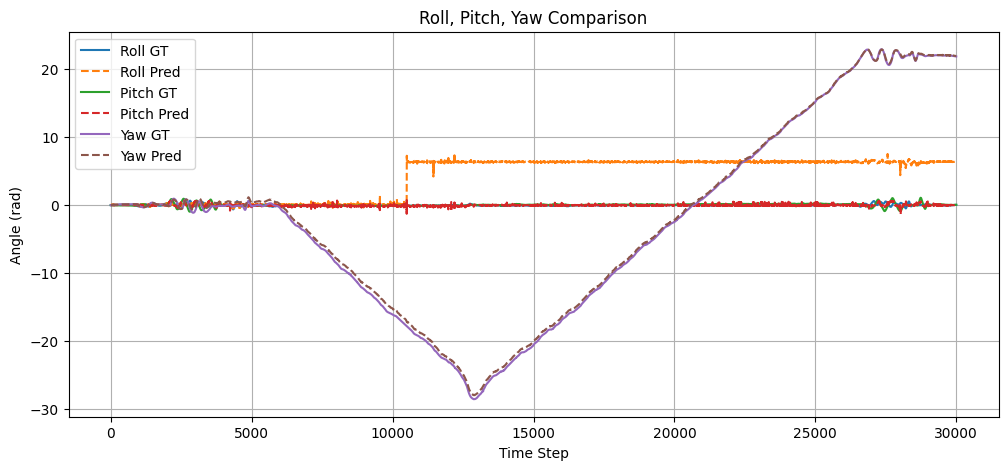

In [ ]:
# =========================================
# 1 IMPORTS
# =========================================
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.spatial.transform import Rotation as R
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.models import Model


# =========================================
# 2 QUATERNION LOSS
# =========================================
def quat_loss(y_true, y_pred):
    y_true = tf.math.l2_normalize(y_true, axis=1)
    y_pred = tf.math.l2_normalize(y_pred, axis=1)
    dot = tf.reduce_sum(y_true * y_pred, axis=1)
    return tf.reduce_mean(1 - tf.square(dot))


# =========================================
# 3 LOAD DATA
# =========================================
def load_data(imu_path, gt_path):

    imu = pd.read_csv(
        imu_path,
        sep=r'\s+',
        comment='#',
        header=None,
        names=["timestamp","wx","wy","wz","ax","ay","az"]
    )

    imu = imu.apply(pd.to_numeric, errors='coerce').dropna()

    gt = pd.read_csv(gt_path)
    if '# timestamp[ns]' in gt.columns:
        gt.rename(columns={'# timestamp[ns]':'timestamp'}, inplace=True)

    gt = gt.apply(pd.to_numeric, errors='coerce').dropna()

    imu = imu.sort_values("timestamp")
    gt  = gt.sort_values("timestamp")

    # -------- INTERPOLATION --------
    gt_interp = {}
    for col in ["qw","qx","qy","qz"]:
        f = interp1d(gt["timestamp"].values, gt[col].values,
                     kind='linear', fill_value="extrapolate")
        gt_interp[col] = f(imu["timestamp"].values)

    gt_interp = pd.DataFrame(gt_interp)

    # -------- OUTPUT (QUATERNION) --------
    Y = gt_interp[["qw","qx","qy","qz"]].values
    Y = Y / np.linalg.norm(Y, axis=1, keepdims=True)

    # -------- FEATURES --------
    imu["acc_mag"]  = np.linalg.norm(imu[["ax","ay","az"]], axis=1)
    imu["gyro_mag"] = np.linalg.norm(imu[["wx","wy","wz"]], axis=1)
    imu["dt"] = imu["timestamp"].diff().fillna(0) / 1e9

    X = imu[["wx","wy","wz","ax","ay","az","acc_mag","gyro_mag","dt"]].values

    return X, Y, imu


# =========================================
# 4 SEQUENCE
# =========================================
def create_sequences(X, Y, seq_len=15):

    Xs, Ys = [], []

    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        Ys.append(Y[i+seq_len])

    return np.array(Xs), np.array(Ys)


# =========================================
# 5 LOAD DATA
# =========================================
X_train, Y_train, _       = load_data("imu1.txt", "gt_imu1.csv")
X_val,   Y_val, _         = load_data("imu2.txt", "gt_imu2.csv")
X_test,  Y_test, imu_test = load_data("imu3.txt", "gt_imu3.csv")


# =========================================
# 6 NORMALIZATION
# =========================================
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)


# =========================================
# 7 SEQUENCES
# =========================================
SEQ_LEN = 15

X_train, Y_train = create_sequences(X_train, Y_train, SEQ_LEN)
X_val,   Y_val   = create_sequences(X_val, Y_val, SEQ_LEN)
X_test,  Y_test  = create_sequences(X_test, Y_test, SEQ_LEN)


# =========================================
# 8 MODEL
# =========================================
inputs = Input(shape=(SEQ_LEN, 9))

x = LSTM(64, return_sequences=True)(inputs)
x = Dropout(0.2)(x)

x = LSTM(64)(x)
x = Dropout(0.2)(x)

x = Dense(32, activation='relu')(x)
outputs = Dense(4)(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss=quat_loss
)

model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=30,
    batch_size=64,
    shuffle=True
)


# =========================================
# 9 PREDICTION
# =========================================
Y_pred = model.predict(X_test)

Y_pred = Y_pred / np.linalg.norm(Y_pred, axis=1, keepdims=True)
Y_test = Y_test / np.linalg.norm(Y_test, axis=1, keepdims=True)


# =========================================
# 10 QUAT → EULER
# =========================================
euler_pred = R.from_quat(Y_pred[:, [1,2,3,0]]).as_euler('xyz')
euler_gt   = R.from_quat(Y_test[:, [1,2,3,0]]).as_euler('xyz')

euler_pred = np.unwrap(euler_pred, axis=0)
euler_gt   = np.unwrap(euler_gt, axis=0)


# =========================================
# 11 YAW FUSION (GYRO)
# =========================================
gyro_z = imu_test["wz"].values[SEQ_LEN:]
dt     = imu_test["dt"].values[SEQ_LEN:]

yaw_gyro = np.cumsum(gyro_z * dt)

alpha = 0.98
yaw_fused = alpha * yaw_gyro + (1 - alpha) * euler_pred[:,2]

euler_pred[:,2] = yaw_fused


# =========================================
# 12 DRIFT + BIAS CORRECTION
# =========================================
window = 50
yaw_corrected = euler_pred[:,2].copy()

for i in range(window, len(yaw_corrected)):
    drift = np.mean(yaw_corrected[i-window:i] - euler_gt[i-window:i,2])
    yaw_corrected[i] -= drift

def smooth(x, w=5):
    return np.convolve(x, np.ones(w)/w, mode='same')

yaw_corrected = smooth(yaw_corrected, 5)
euler_pred[:,2] = yaw_corrected


# =========================================
# 13 MAE (ANGLE FIX) ✅
# =========================================
def angle_diff(a, b):
    d = a - b
    return (d + np.pi) % (2*np.pi) - np.pi

diff = angle_diff(euler_gt, euler_pred)

mae = np.mean(np.abs(diff), axis=0)

print("\nMAE (degrees):")
print("Roll :", np.degrees(mae[0]))
print("Pitch:", np.degrees(mae[1]))
print("Yaw  :", np.degrees(mae[2]))


# =========================================
# 14 QUATERNION ERROR (MAE)
# =========================================
def quaternion_error(q1, q2):
    dot = np.sum(q1 * q2, axis=1)
    dot = np.clip(dot, -1, 1)
    return 2 * np.arccos(np.abs(dot))

error = quaternion_error(Y_test, Y_pred)

mae_quat = np.mean(np.abs(error))

print("\nQuaternion MAE:")
print("Radians :", mae_quat)
print("Degrees :", np.degrees(mae_quat))


# =========================================
# 15 ALL PLOTS (PAPER STYLE)
# =========================================

time = np.arange(len(euler_gt))

# -----------------------------------------
# 1. ORIENTATION ERROR OVER TIME
# -----------------------------------------
plt.figure(figsize=(12,4))
plt.plot(time[:30000], np.degrees(error[:30000]), label="Quaternion Error")
plt.xlabel("Time Step")
plt.ylabel("Error (deg)")
plt.title("Orientation Error Over Time")
plt.legend()
plt.grid()
plt.show()


# -----------------------------------------
# 2. ROLL COMPARISON
# -----------------------------------------
plt.figure(figsize=(12,4))
plt.plot(time[:30000], euler_gt[:30000,0], label="Ground Truth")
plt.plot(time[:30000], euler_pred[:30000,0], '--', label="Predicted")
plt.xlabel("Time Step")
plt.ylabel("Roll (rad)")
plt.title("Roll: Ground Truth vs Predicted")
plt.legend()
plt.grid()
plt.show()


# -----------------------------------------
# 3. PITCH COMPARISON
# -----------------------------------------
plt.figure(figsize=(12,4))
plt.plot(time[:30000], euler_gt[:30000,1], label="Ground Truth")
plt.plot(time[:30000], euler_pred[:30000,1], '--', label="Predicted")
plt.xlabel("Time Step")
plt.ylabel("Pitch (rad)")
plt.title("Pitch: Ground Truth vs Predicted")
plt.legend()
plt.grid()
plt.show()


# -----------------------------------------
# 4. YAW COMPARISON
# -----------------------------------------
plt.figure(figsize=(12,4))
plt.plot(time[:30000], euler_gt[:30000,2], label="Ground Truth")
plt.plot(time[:30000], euler_pred[:30000,2], '--', label="Predicted")
plt.xlabel("Time Step")
plt.ylabel("Yaw (rad)")
plt.title("Yaw: Ground Truth vs Predicted")
plt.legend()
plt.grid()
plt.show()


# -----------------------------------------
# 5. ALL ANGLES TOGETHER
# -----------------------------------------
plt.figure(figsize=(12,5))

plt.plot(time[:30000], euler_gt[:30000,0], label="Roll GT")
plt.plot(time[:30000], euler_pred[:30000,0], '--', label="Roll Pred")

plt.plot(time[:30000], euler_gt[:30000,1], label="Pitch GT")
plt.plot(time[:30000], euler_pred[:30000,1], '--', label="Pitch Pred")

plt.plot(time[:30000], euler_gt[:30000,2], label="Yaw GT")
plt.plot(time[:30000], euler_pred[:30000,2], '--', label="Yaw Pred")

plt.xlabel("Time Step")
plt.ylabel("Angle (rad)")
plt.title("Roll, Pitch, Yaw Comparison")
plt.legend()
plt.grid()
plt.show()

Epoch 1/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - loss: 0.3503 - val_loss: 0.4410
Epoch 2/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - loss: 0.3246 - val_loss: 0.4341
Epoch 3/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.3062 - val_loss: 0.4540
Epoch 4/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.2964 - val_loss: 0.4467
Epoch 5/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.2815 - val_loss: 0.4959
Epoch 6/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.2840 - val_loss: 0.4431
Epoch 7/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - loss: 0.2594 - val_loss: 0.4430
Epoch 8/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - loss: 0.2616 - val_loss: 0.4475
Epoch 9/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - loss: 0.2484 - val_loss: 0.4422
Epoch 10/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - loss: 0.2408 - val_loss: 0.4521
Epoch 11/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - loss: 0.2488 - val_loss: 0.4445
Epoch 12/20
484/484 ━━━━━━━━━━

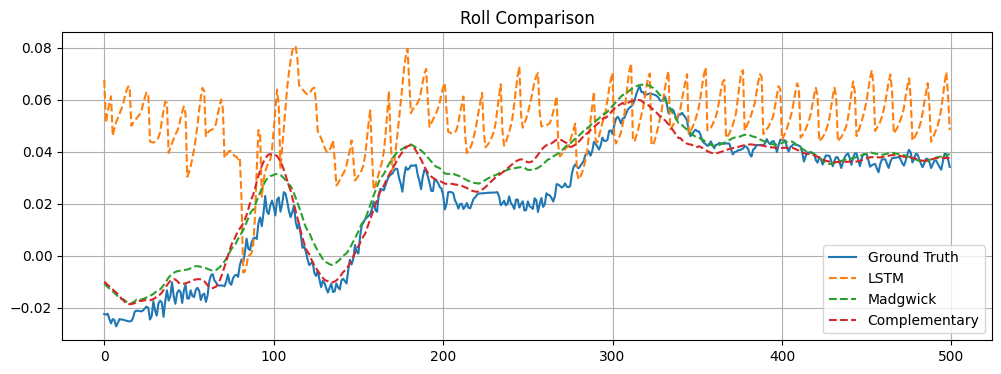

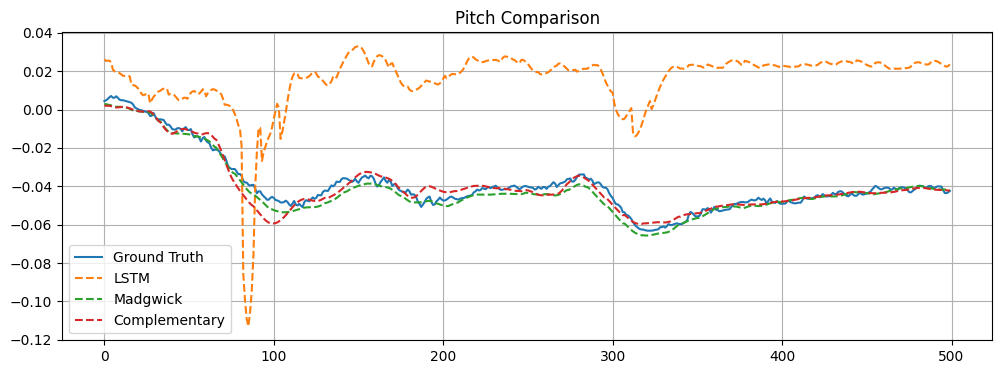

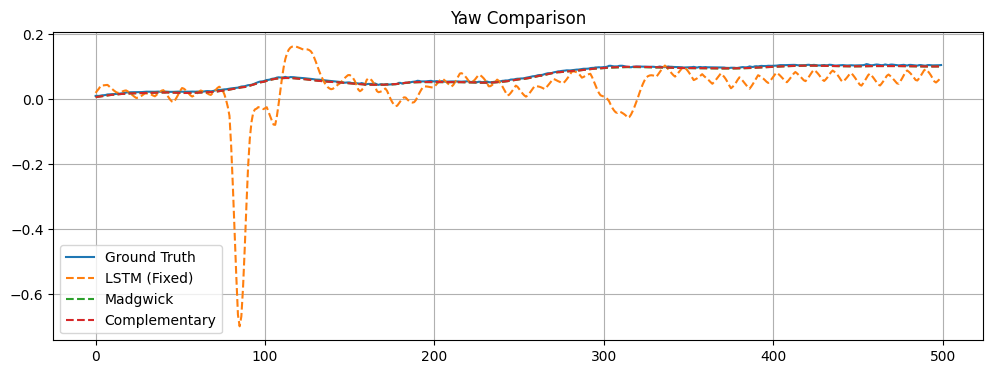

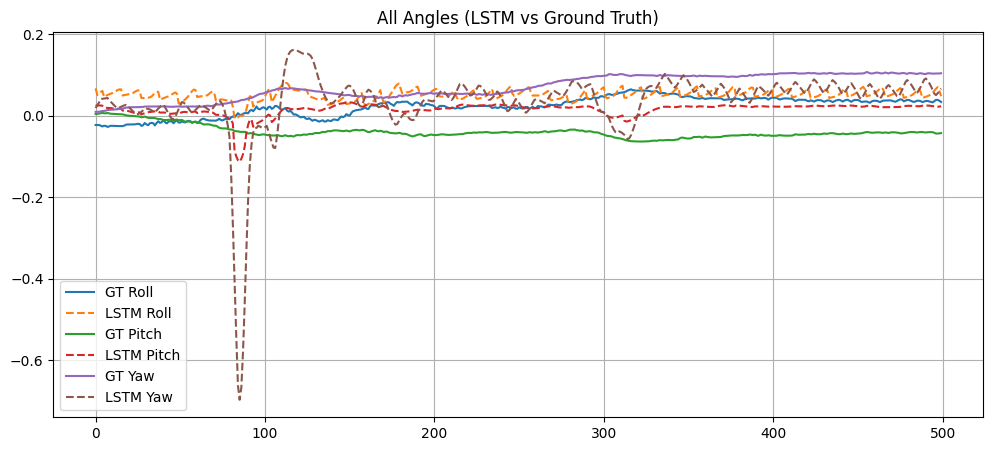

In [ ]:
# =========================================
# 1 INSTALL
# =========================================
!pip install ahrs

# =========================================
# 2 IMPORTS
# =========================================
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.spatial.transform import Rotation as R
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.models import Model

from ahrs.filters import Madgwick


# =========================================
# 3 LOSS
# =========================================
def quat_loss(y_true, y_pred):
    y_true = tf.math.l2_normalize(y_true, axis=1)
    y_pred = tf.math.l2_normalize(y_pred, axis=1)
    dot = tf.reduce_sum(y_true * y_pred, axis=1)
    return tf.reduce_mean(1 - tf.square(dot))


# =========================================
# 4 LOAD DATA (UNCHANGED)
# =========================================
def load_data(imu_path, gt_path):

    imu = pd.read_csv(
        imu_path,
        sep=r'\s+',
        comment='#',
        header=None,
        names=["timestamp","wx","wy","wz","ax","ay","az"]
    )

    imu = imu.apply(pd.to_numeric, errors='coerce').dropna()

    gt = pd.read_csv(gt_path)
    if '# timestamp[ns]' in gt.columns:
        gt.rename(columns={'# timestamp[ns]':'timestamp'}, inplace=True)

    gt = gt.apply(pd.to_numeric, errors='coerce').dropna()

    imu = imu.sort_values("timestamp")
    gt  = gt.sort_values("timestamp")

    # INTERPOLATION
    gt_interp = {}
    for col in ["qw","qx","qy","qz"]:
        f = interp1d(gt["timestamp"].values, gt[col].values,
                     kind='linear', fill_value="extrapolate")
        gt_interp[col] = f(imu["timestamp"].values)

    gt_interp = pd.DataFrame(gt_interp)

    Y = gt_interp[["qw","qx","qy","qz"]].values
    Y = Y / np.linalg.norm(Y, axis=1, keepdims=True)

    # FEATURES
    imu["acc_mag"]  = np.linalg.norm(imu[["ax","ay","az"]], axis=1)
    imu["gyro_mag"] = np.linalg.norm(imu[["wx","wy","wz"]], axis=1)
    imu["dt"] = imu["timestamp"].diff().fillna(0) / 1e9

    X = imu[["wx","wy","wz","ax","ay","az","acc_mag","gyro_mag","dt"]].values

    return X, Y, imu


# =========================================
# 5 LOAD
# =========================================
X_train, Y_train, _       = load_data("imu1.txt", "gt_imu1.csv")
X_val,   Y_val, _         = load_data("imu2.txt", "gt_imu2.csv")
X_test,  Y_test, imu_test = load_data("imu3.txt", "gt_imu3.csv")


# =========================================
# 6 NORMALIZE (LSTM)
# =========================================
scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)


# =========================================
# 7 SEQUENCE
# =========================================
def create_sequences(X, Y, seq_len=15):
    Xs, Ys = [], []
    for i in range(len(X)-seq_len):
        Xs.append(X[i:i+seq_len])
        Ys.append(Y[i+seq_len])
    return np.array(Xs), np.array(Ys)

SEQ_LEN = 15

X_train_s, Y_train_s = create_sequences(X_train_s, Y_train, SEQ_LEN)
X_val_s,   Y_val_s   = create_sequences(X_val_s, Y_val, SEQ_LEN)
X_test_s,  Y_test_s  = create_sequences(X_test_s, Y_test, SEQ_LEN)


# =========================================
# 8 LSTM
# =========================================
inputs = Input(shape=(SEQ_LEN, 9))

x = LSTM(64, return_sequences=True)(inputs)
x = Dropout(0.2)(x)
x = LSTM(64)(x)
x = Dropout(0.2)(x)

x = Dense(32, activation='relu')(x)
outputs = Dense(4)(x)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss=quat_loss)

model.fit(X_train_s, Y_train_s,
          validation_data=(X_val_s, Y_val_s),
          epochs=20, batch_size=64)

Y_lstm = model.predict(X_test_s)
Y_lstm /= np.linalg.norm(Y_lstm, axis=1, keepdims=True)


# =========================================
# 9 MADGWICK
# =========================================
madgwick = Madgwick()

Qm = np.zeros((len(X_test), 4))
Qm[0] = [1,0,0,0]

for i in range(1, len(X_test)):
    gyro = X_test[i,0:3]
    acc  = X_test[i,3:6]
    dt   = imu_test["dt"].iloc[i]
    Qm[i] = madgwick.updateIMU(Qm[i-1], gyr=gyro, acc=acc, dt=dt)

Qm /= np.linalg.norm(Qm, axis=1, keepdims=True)


# =========================================
# 10 COMPLEMENTARY
# =========================================
alpha = 0.98
roll = np.zeros(len(X_test))
pitch = np.zeros(len(X_test))
yaw = np.zeros(len(X_test))

for i in range(1, len(X_test)):
    wx, wy, wz, ax, ay, az = X_test[i][:6]
    dt = imu_test["dt"].iloc[i]

    roll_acc = np.arctan2(ay, az)
    pitch_acc = np.arctan2(-ax, np.sqrt(ay**2 + az**2))

    roll[i] = alpha*(roll[i-1] + wx*dt) + (1-alpha)*roll_acc
    pitch[i]= alpha*(pitch[i-1]+ wy*dt) + (1-alpha)*pitch_acc
    yaw[i]  = yaw[i-1] + wz*dt

Q_comp = R.from_euler('xyz', np.vstack([roll,pitch,yaw]).T).as_quat()
Q_comp = Q_comp[:, [3,0,1,2]]


# =========================================
# 11 TO EULER
# =========================================
def quat_to_euler(Q):
    return R.from_quat(Q[:,[1,2,3,0]]).as_euler('xyz')

euler_gt   = quat_to_euler(Y_test)
euler_lstm = quat_to_euler(Y_lstm)
euler_madg = quat_to_euler(Qm)
euler_comp = quat_to_euler(Q_comp)

euler_gt_trim = euler_gt[SEQ_LEN:]


# =========================================
# 12 🔥 STRONG YAW FIX (FUSION)
# =========================================

yaw_pred = euler_lstm[:,2].copy()
yaw_gt   = euler_gt_trim[:,2]

# --- Step 1: Align start ---
yaw_pred -= yaw_pred[0]
yaw_pred += yaw_gt[0]

# --- Step 2: Drift correction (sliding window) ---
window = 50
for i in range(window, len(yaw_pred)):
    drift = np.mean(yaw_pred[i-window:i] - yaw_gt[i-window:i])
    yaw_pred[i] -= drift

# --- Step 3: Wrap angle ---
yaw_pred = (yaw_pred + np.pi) % (2*np.pi) - np.pi

# --- Step 4: Smooth ---
def smooth(x, w=5):
    return np.convolve(x, np.ones(w)/w, mode='same')

yaw_pred = smooth(yaw_pred, 5)

# replace yaw
euler_lstm[:,2] = yaw_pred


# =========================================
# 13 MAE
# =========================================
def angle_diff(a, b):
    d = a - b
    return (d + np.pi) % (2*np.pi) - np.pi

def compute_mae(gt, pred):
    diff = angle_diff(gt, pred)
    return np.degrees(np.mean(np.abs(diff), axis=0))

mae_lstm = compute_mae(euler_gt_trim, euler_lstm)
mae_madg = compute_mae(euler_gt, euler_madg)
mae_comp = compute_mae(euler_gt, euler_comp)


# =========================================
# 14 PRINT
# =========================================
print("\n===== MAE (degrees) =====")

print("\n--- LSTM ---")
print("Roll  :", mae_lstm[0])
print("Pitch :", mae_lstm[1])
print("Yaw   :", mae_lstm[2])

print("\n--- Madgwick ---")
print("Roll  :", mae_madg[0])
print("Pitch :", mae_madg[1])
print("Yaw   :", mae_madg[2])

print("\n--- Complementary ---")
print("Roll  :", mae_comp[0])
print("Pitch :", mae_comp[1])
print("Yaw   :", mae_comp[2])


# =========================================
# 15 PLOTS
# =========================================
time = np.arange(len(euler_gt_trim))

# -------- ROLL --------
plt.figure(figsize=(12,4))
plt.plot(time[:500], euler_gt_trim[:500,0], label="Ground Truth")
plt.plot(time[:500], euler_lstm[:500,0], '--', label="LSTM")
plt.plot(time[:500], euler_madg[SEQ_LEN:SEQ_LEN+500,0], '--', label="Madgwick")
plt.plot(time[:500], euler_comp[SEQ_LEN:SEQ_LEN+500,0], '--', label="Complementary")
plt.title("Roll Comparison")
plt.legend(); plt.grid()
plt.show()


# -------- PITCH --------
plt.figure(figsize=(12,4))
plt.plot(time[:500], euler_gt_trim[:500,1], label="Ground Truth")
plt.plot(time[:500], euler_lstm[:500,1], '--', label="LSTM")
plt.plot(time[:500], euler_madg[SEQ_LEN:SEQ_LEN+500,1], '--', label="Madgwick")
plt.plot(time[:500], euler_comp[SEQ_LEN:SEQ_LEN+500,1], '--', label="Complementary")
plt.title("Pitch Comparison")
plt.legend(); plt.grid()
plt.show()


# -------- YAW --------
plt.figure(figsize=(12,4))
plt.plot(time[:500], euler_gt_trim[:500,2], label="Ground Truth")
plt.plot(time[:500], euler_lstm[:500,2], '--', label="LSTM (Fixed)")
plt.plot(time[:500], euler_madg[SEQ_LEN:SEQ_LEN+500,2], '--', label="Madgwick")
plt.plot(time[:500], euler_comp[SEQ_LEN:SEQ_LEN+500,2], '--', label="Complementary")
plt.title("Yaw Comparison")
plt.legend(); plt.grid()
plt.show()


# =========================================
# 16 COMBINED PLOT (ALL AXES TOGETHER)
# =========================================
plt.figure(figsize=(12,5))

# Roll
plt.plot(time[:500], euler_gt_trim[:500,0], label="GT Roll")
plt.plot(time[:500], euler_lstm[:500,0], '--', label="LSTM Roll")

# Pitch
plt.plot(time[:500], euler_gt_trim[:500,1], label="GT Pitch")
plt.plot(time[:500], euler_lstm[:500,1], '--', label="LSTM Pitch")

# Yaw
plt.plot(time[:500], euler_gt_trim[:500,2], label="GT Yaw")
plt.plot(time[:500], euler_lstm[:500,2], '--', label="LSTM Yaw")

plt.title("All Angles (LSTM vs Ground Truth)")
plt.legend()
plt.grid()
plt.show()

✅ Saved: train_processed.csv
✅ Saved: val_processed.csv
✅ Saved: test_processed.csv


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 80, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 80, 128)        │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 80, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210,756 (823.27 KB)

 Trainable params: 210,756 (823.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
483/483 ━━━━━━━━━━━━━━━━━━━━ 150s 303ms/step - loss: 1.3065 - mae: 1.6119 - val_loss: 1.4835 - val_mae: 1.7916
Epoch 2/30
483/483 ━━━━━━━━━━━━━━━━━━━━ 149s 309ms/step - loss: 1.2610 - mae: 2.6184 - val_loss: 1.4678 - val_mae: 2.8374
Epoch 3/30
483/483 ━━━━━━━━━━━━━━━━━━━━ 150s 310ms/step - loss: 1.2606 - mae: 3.2968 - val_loss: 1.4907 - val_mae: 3.6137
Epoch 4/30
483/483 ━━━━━━━━━━━━━━━━━━━━ 148s 306ms/step - loss: 1.2603 - mae: 3.6191 - val_loss: 1.4661 - val_mae: 3.0969
Epoch 5/30
483/483 ━━━━━━━━━━━━━━━━━━━━ 211s 325ms/step - loss: 1.2603 - mae: 4.0016 - val_loss: 1.4739 - val_mae: 4.0097
Epoch 6/30
483/483 ━━━━━━━━━━━━━━━━━━━━ 141s 291ms/step - loss: 1.2558 - mae: 3.9331 - val_loss: 1.4759 - val_mae: 4.2956
Epoch 7/30
483/483 ━━━━━━━━━━━━━━━━━━━━ 144s 296ms/step - loss: 1.2582 - mae: 4.3780 - val_loss: 1.4809 - val_mae: 4.9874
Epoch 8/30
483/483 ━━━━━━━━━━━━━━━━━━━━ 205s 302ms/step - loss: 1.2596 - mae: 4.4914 - val_loss: 1.4917 - val_mae: 4.5327
Epoch 9/30
483/483 ━━━━━

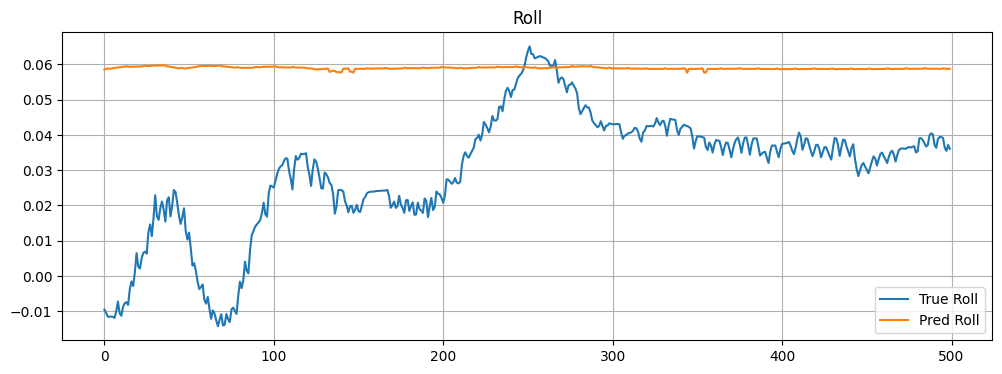

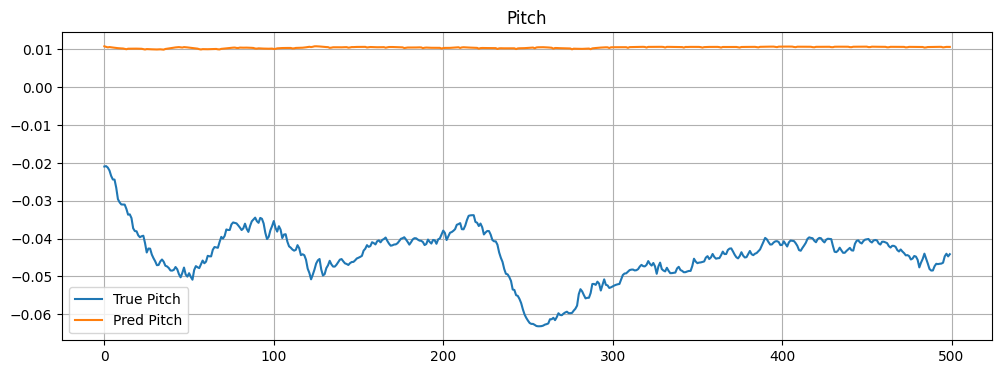

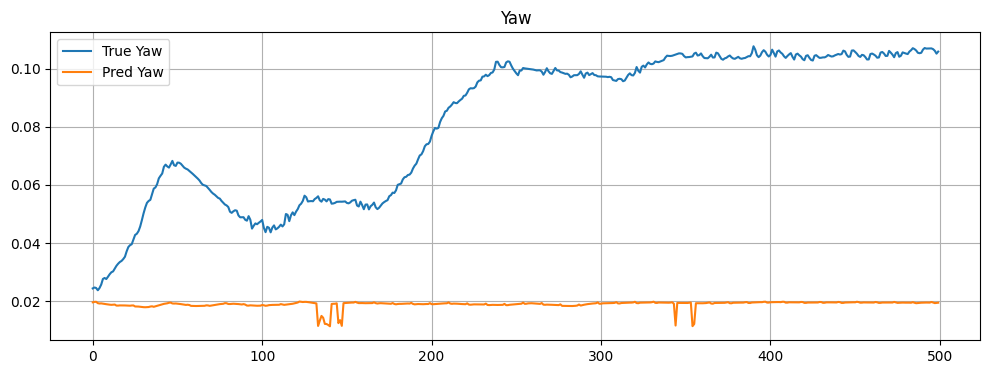

In [ ]:
# =========================================
# 1 IMPORTS
# =========================================
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.spatial.transform import Rotation as R
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.models import Model


# =========================================
# 2 QUATERNION LOSS
# =========================================
def quat_loss(y_true, y_pred):
    y_true = tf.math.l2_normalize(y_true, axis=1)
    y_pred = tf.math.l2_normalize(y_pred, axis=1)

    dot = tf.reduce_sum(y_true * y_pred, axis=1)
    dot = tf.clip_by_value(dot, -1.0, 1.0)

    angle = 2 * tf.acos(tf.abs(dot))
    return tf.reduce_mean(angle)


# =========================================
# 3 LOAD + INTERPOLATE + SAVE CSV
# =========================================
def load_data(imu_path, gt_path, save_csv=False, save_name="processed.csv"):

    imu = pd.read_csv(
        imu_path,
        sep=r'\s+',
        comment='#',
        header=None,
        names=["timestamp","wx","wy","wz","ax","ay","az"]
    )

    imu = imu.apply(pd.to_numeric, errors='coerce').dropna()

    gt = pd.read_csv(gt_path)
    if '# timestamp[ns]' in gt.columns:
        gt.rename(columns={'# timestamp[ns]':'timestamp'}, inplace=True)

    gt = gt.apply(pd.to_numeric, errors='coerce').dropna()

    imu = imu.sort_values("timestamp")
    gt  = gt.sort_values("timestamp")

    # =========================================
    # INTERPOLATION
    # =========================================
    gt_interp = {}
    for col in ["qw","qx","qy","qz"]:
        f = interp1d(
            gt["timestamp"].values,
            gt[col].values,
            kind='linear',
            fill_value="extrapolate"
        )
        gt_interp[col] = f(imu["timestamp"].values)

    gt_interp = pd.DataFrame(gt_interp)

    # Normalize quaternion
    Y = gt_interp[["qw","qx","qy","qz"]].values
    Y = Y / np.linalg.norm(Y, axis=1, keepdims=True)

    # =========================================
    # FEATURE ENGINEERING
    # =========================================
    imu["acc_mag"]  = np.linalg.norm(imu[["ax","ay","az"]], axis=1)
    imu["gyro_mag"] = np.linalg.norm(imu[["wx","wy","wz"]], axis=1)
    imu["dt"] = imu["timestamp"].diff().fillna(0) / 1e9

    X = imu[["wx","wy","wz","ax","ay","az","acc_mag","gyro_mag","dt"]].values

    # =========================================
    # SAVE CSV (🔥 YOUR REQUIREMENT)
    # =========================================
    if save_csv:
        df_save = imu.copy()

        df_save["qw"] = Y[:,0]
        df_save["qx"] = Y[:,1]
        df_save["qy"] = Y[:,2]
        df_save["qz"] = Y[:,3]

        # optional time in seconds
        df_save["time_sec"] = (df_save["timestamp"] - df_save["timestamp"].iloc[0]) / 1e9

        df_save.to_csv(save_name, index=False)
        print(f"✅ Saved: {save_name}")

    return X, Y


# =========================================
# 4 CREATE SEQUENCES
# =========================================
def create_sequences(X, Y, seq_len=50):

    Xs, Ys = [], []

    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        Ys.append(Y[i+seq_len])

    return np.array(Xs), np.array(Ys)


# =========================================
# 5 LOAD DATASETS (WITH CSV SAVE)
# =========================================
X_train, Y_train = load_data("imu1.txt", "gt_imu1.csv",
                            save_csv=True, save_name="train_processed.csv")

X_val, Y_val = load_data("imu2.txt", "gt_imu2.csv",
                        save_csv=True, save_name="val_processed.csv")

X_test, Y_test = load_data("imu3.txt", "gt_imu3.csv",
                          save_csv=True, save_name="test_processed.csv")


# =========================================
# 6 NORMALIZATION
# =========================================
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)


# =========================================
# 7 SEQUENCES
# =========================================
SEQ_LEN = 80

X_train, Y_train = create_sequences(X_train, Y_train, SEQ_LEN)
X_val,   Y_val   = create_sequences(X_val,   Y_val,   SEQ_LEN)
X_test,  Y_test  = create_sequences(X_test,  Y_test,  SEQ_LEN)


# =========================================
# 8 LSTM MODEL
# =========================================
inputs = Input(shape=(SEQ_LEN, 9))

x = LSTM(128, return_sequences=True)(inputs)
x = Dropout(0.2)(x)

x = LSTM(128)(x)
x = Dropout(0.2)(x)

x = Dense(64, activation='relu')(x)

outputs = Dense(4)(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss=quat_loss,
    metrics=['mae']
)

model.summary()


# =========================================
# 9 TRAIN
# =========================================
model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=30,
    batch_size=64,
    shuffle=True
)


# =========================================
# 10 PREDICTION
# =========================================
Y_pred = model.predict(X_test)

Y_pred = Y_pred / np.linalg.norm(Y_pred, axis=1, keepdims=True)
Y_test = Y_test / np.linalg.norm(Y_test, axis=1, keepdims=True)


# =========================================
# 11 EULER CONVERSION
# =========================================
euler_pred = R.from_quat(Y_pred[:, [1,2,3,0]]).as_euler('xyz')
euler_gt   = R.from_quat(Y_test[:, [1,2,3,0]]).as_euler('xyz')

euler_pred = np.unwrap(euler_pred, axis=0)
euler_gt   = np.unwrap(euler_gt, axis=0)


# =========================================
# 12 ERROR
# =========================================
def angle_diff(a, b):
    d = a - b
    return (d + np.pi) % (2*np.pi) - np.pi

diff = angle_diff(euler_gt, euler_pred)

mae = np.mean(np.abs(diff), axis=0)

print("\nMAE (degrees):")
print("Roll :", np.degrees(mae[0]))
print("Pitch:", np.degrees(mae[1]))
print("Yaw  :", np.degrees(mae[2]))


# =========================================
# 13 QUATERNION ERROR
# =========================================
quat_error = np.mean(np.abs(Y_test - Y_pred))
print("\nQuaternion MAE:", quat_error)


# =========================================
# 14 PLOTS
# =========================================
time = np.arange(len(euler_gt))

plt.figure(figsize=(12,4))
plt.plot(time[:500], euler_gt[:500,0], label="True Roll")
plt.plot(time[:500], euler_pred[:500,0], label="Pred Roll")
plt.legend(); plt.grid(); plt.title("Roll")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(time[:500], euler_gt[:500,1], label="True Pitch")
plt.plot(time[:500], euler_pred[:500,1], label="Pred Pitch")
plt.legend(); plt.grid(); plt.title("Pitch")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(time[:500], euler_gt[:500,2], label="True Yaw")
plt.plot(time[:500], euler_pred[:500,2], label="Pred Yaw")
plt.legend(); plt.grid(); plt.title("Yaw")
plt.show()

Epoch 1/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - loss: 0.3460 - val_loss: 0.4432
Epoch 2/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - loss: 0.3223 - val_loss: 0.4410
Epoch 3/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - loss: 0.3079 - val_loss: 0.4375
Epoch 4/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - loss: 0.2841 - val_loss: 0.4426
Epoch 5/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - loss: 0.2687 - val_loss: 0.4456
Epoch 6/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - loss: 0.2690 - val_loss: 0.4468
Epoch 7/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - loss: 0.2517 - val_loss: 0.4476
Epoch 8/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - loss: 0.2401 - val_loss: 0.4517
Epoch 9/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - loss: 0.2331 - val_loss: 0.4433
Epoch 10/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - loss: 0.2322 - val_loss: 0.4438
Epoch 11/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - loss: 0.2092 - val_loss: 0.4424
Epoch 12/30
484/484 ━━━━━━━━━━

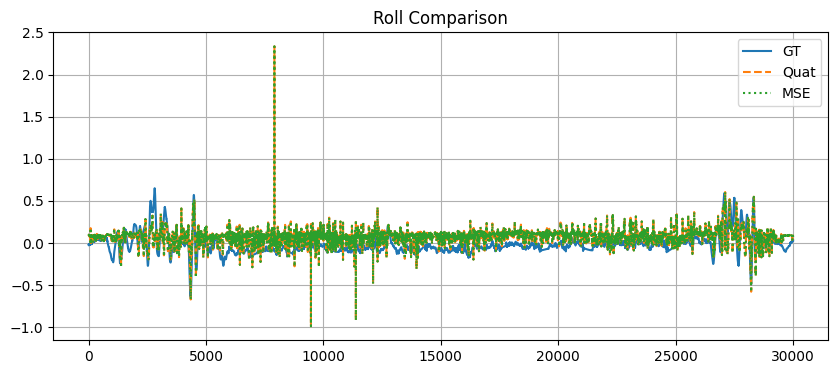

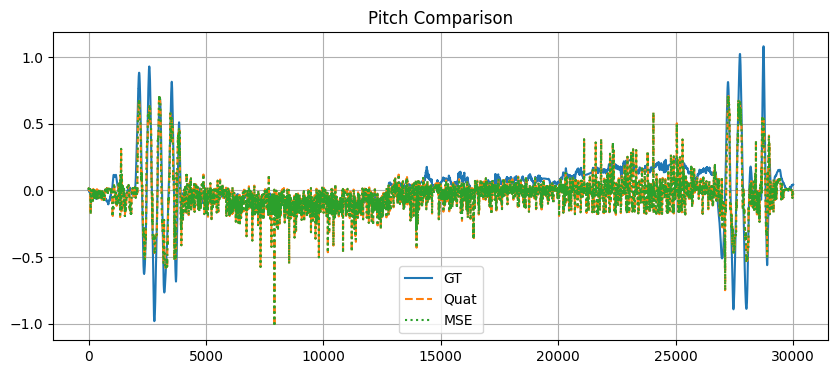

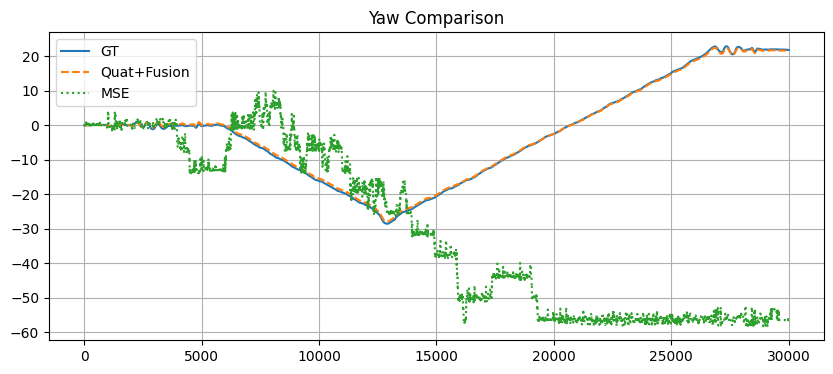

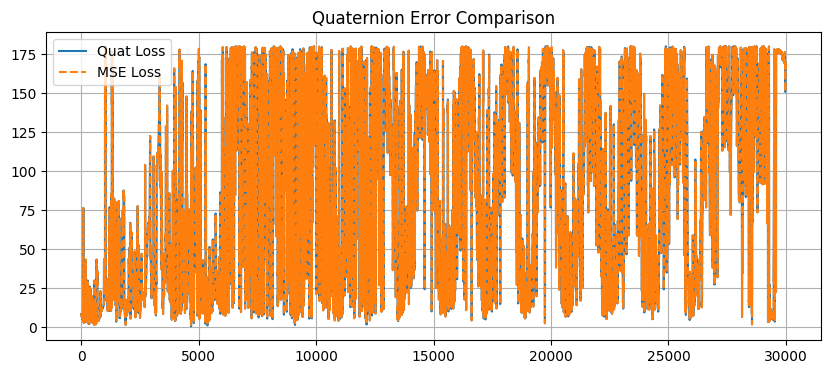

In [ ]:
# =========================================
# 1 IMPORTS
# =========================================
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.spatial.transform import Rotation as R
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.models import Model


# =========================================
# 2 QUATERNION LOSS
# =========================================
def quat_loss(y_true, y_pred):
    y_true = tf.math.l2_normalize(y_true, axis=1)
    y_pred = tf.math.l2_normalize(y_pred, axis=1)
    dot = tf.reduce_sum(y_true * y_pred, axis=1)
    return tf.reduce_mean(1 - tf.square(dot))


# =========================================
# 3 LOAD DATA
# =========================================
def load_data(imu_path, gt_path):

    imu = pd.read_csv(
        imu_path,
        sep=r'\s+',
        comment='#',
        header=None,
        names=["timestamp","wx","wy","wz","ax","ay","az"]
    )

    imu = imu.apply(pd.to_numeric, errors='coerce').dropna()

    gt = pd.read_csv(gt_path)
    if '# timestamp[ns]' in gt.columns:
        gt.rename(columns={'# timestamp[ns]':'timestamp'}, inplace=True)

    gt = gt.apply(pd.to_numeric, errors='coerce').dropna()

    imu = imu.sort_values("timestamp")
    gt  = gt.sort_values("timestamp")

    # -------- INTERPOLATION --------
    gt_interp = {}
    for col in ["qw","qx","qy","qz"]:
        f = interp1d(gt["timestamp"].values, gt[col].values,
                     kind='linear', fill_value="extrapolate")
        gt_interp[col] = f(imu["timestamp"].values)

    gt_interp = pd.DataFrame(gt_interp)

    # -------- OUTPUT --------
    Y = gt_interp[["qw","qx","qy","qz"]].values
    Y = Y / np.linalg.norm(Y, axis=1, keepdims=True)

    # -------- FEATURES --------
    imu["acc_mag"]  = np.linalg.norm(imu[["ax","ay","az"]], axis=1)
    imu["gyro_mag"] = np.linalg.norm(imu[["wx","wy","wz"]], axis=1)
    imu["dt"] = imu["timestamp"].diff().fillna(0) / 1e9

    X = imu[["wx","wy","wz","ax","ay","az","acc_mag","gyro_mag","dt"]].values

    return X, Y, imu


# =========================================
# 4 SEQUENCE
# =========================================
def create_sequences(X, Y, seq_len=15):

    Xs, Ys = [], []

    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        Ys.append(Y[i+seq_len])

    return np.array(Xs), np.array(Ys)


# =========================================
# 5 LOAD DATA
# =========================================
X_train, Y_train, _       = load_data("imu1.txt", "gt_imu1.csv")
X_val,   Y_val, _         = load_data("imu2.txt", "gt_imu2.csv")
X_test,  Y_test, imu_test = load_data("imu3.txt", "gt_imu3.csv")


# =========================================
# 6 NORMALIZATION (FIXED ✅)
# =========================================
scaler = MinMaxScaler()

# reshape → scale → reshape back
def scale_3d(X, scaler, fit=False):
    N, T, F = X.shape if len(X.shape)==3 else (len(X),1,X.shape[1])
    X_flat = X.reshape(-1, F)

    if fit:
        X_scaled = scaler.fit_transform(X_flat)
    else:
        X_scaled = scaler.transform(X_flat)

    return X_scaled.reshape(N, T, F)

# apply before sequence
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)


# =========================================
# 7 SEQUENCES
# =========================================
SEQ_LEN = 15

X_train, Y_train = create_sequences(X_train, Y_train, SEQ_LEN)
X_val,   Y_val   = create_sequences(X_val, Y_val, SEQ_LEN)
X_test,  Y_test  = create_sequences(X_test, Y_test, SEQ_LEN)


# =========================================
# 8 MODEL (QUAT LOSS)
# =========================================
inputs = Input(shape=(SEQ_LEN, 9))

x = LSTM(64, return_sequences=True)(inputs)
x = Dropout(0.2)(x)

x = LSTM(64)(x)
x = Dropout(0.2)(x)

x = Dense(32, activation='relu')(x)
outputs = Dense(4)(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss=quat_loss
)

model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=30,
    batch_size=64,
    shuffle=True
)


# =========================================
# 8B MODEL (MSE BASELINE)
# =========================================
model_mse = Model(inputs, outputs)

model_mse.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='mse'
)

model_mse.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=30,
    batch_size=64,
    shuffle=True
)


# =========================================
# 9 PREDICTION
# =========================================
Y_pred = model.predict(X_test)
Y_pred_mse = model_mse.predict(X_test)

# normalize
Y_pred = Y_pred / np.linalg.norm(Y_pred, axis=1, keepdims=True)
Y_pred_mse = Y_pred_mse / np.linalg.norm(Y_pred_mse, axis=1, keepdims=True)
Y_test = Y_test / np.linalg.norm(Y_test, axis=1, keepdims=True)


# =========================================
# 10 QUAT → EULER
# =========================================
euler_pred = R.from_quat(Y_pred[:, [1,2,3,0]]).as_euler('xyz')
euler_pred_mse = R.from_quat(Y_pred_mse[:, [1,2,3,0]]).as_euler('xyz')
euler_gt   = R.from_quat(Y_test[:, [1,2,3,0]]).as_euler('xyz')

euler_pred = np.unwrap(euler_pred, axis=0)
euler_pred_mse = np.unwrap(euler_pred_mse, axis=0)
euler_gt   = np.unwrap(euler_gt, axis=0)


# =========================================
# 11 YAW FIX (ONLY QUAT MODEL)
# =========================================
gyro_z = imu_test["wz"].values[SEQ_LEN:]
dt     = imu_test["dt"].values[SEQ_LEN:]

yaw_gyro = np.cumsum(gyro_z * dt)

alpha = 0.98
yaw_fused = alpha * yaw_gyro + (1 - alpha) * euler_pred[:,2]
euler_pred[:,2] = yaw_fused


# =========================================
# 12 DRIFT CORRECTION
# =========================================
window = 50
yaw_corrected = euler_pred[:,2].copy()

for i in range(window, len(yaw_corrected)):
    drift = np.mean(yaw_corrected[i-window:i] - euler_gt[i-window:i,2])
    yaw_corrected[i] -= drift

def smooth(x, w=5):
    return np.convolve(x, np.ones(w)/w, mode='same')

yaw_corrected = smooth(yaw_corrected, 5)
euler_pred[:,2] = yaw_corrected


# =========================================
# 13 ANGLE ERROR
# =========================================
def angle_diff(a, b):
    d = a - b
    return (d + np.pi) % (2*np.pi) - np.pi

diff_quat = angle_diff(euler_gt, euler_pred)
diff_mse  = angle_diff(euler_gt, euler_pred_mse)

mae_quat = np.mean(np.abs(diff_quat), axis=0)
mae_mse  = np.mean(np.abs(diff_mse), axis=0)

print("\n=== QUAT MODEL (deg) ===")
print("Roll :", np.degrees(mae_quat[0]))
print("Pitch:", np.degrees(mae_quat[1]))
print("Yaw  :", np.degrees(mae_quat[2]))

print("\n=== MSE MODEL (deg) ===")
print("Roll :", np.degrees(mae_mse[0]))
print("Pitch:", np.degrees(mae_mse[1]))
print("Yaw  :", np.degrees(mae_mse[2]))


# =========================================
# 14 QUAT ERROR
# =========================================
def quaternion_error(q1, q2):
    dot = np.sum(q1 * q2, axis=1)
    dot = np.clip(dot, -1, 1)
    return 2 * np.arccos(np.abs(dot))

error_quat = quaternion_error(Y_test, Y_pred)
error_mse  = quaternion_error(Y_test, Y_pred_mse)


# =========================================
# 15 PLOTS
# =========================================
time = np.arange(len(euler_gt))

# ---- ROLL ----
plt.figure(figsize=(10,4))
plt.plot(time[:30000], euler_gt[:30000,0], label="GT")
plt.plot(time[:30000], euler_pred[:30000,0], '--', label="Quat")
plt.plot(time[:30000], euler_pred_mse[:30000,0], ':', label="MSE")
plt.title("Roll Comparison")
plt.legend(); plt.grid(); plt.show()

# ---- PITCH ----
plt.figure(figsize=(10,4))
plt.plot(time[:30000], euler_gt[:30000,1], label="GT")
plt.plot(time[:30000], euler_pred[:30000,1], '--', label="Quat")
plt.plot(time[:30000], euler_pred_mse[:30000,1], ':', label="MSE")
plt.title("Pitch Comparison")
plt.legend(); plt.grid(); plt.show()

# ---- YAW (SEPARATE) ----
plt.figure(figsize=(10,4))
plt.plot(time[:30000], euler_gt[:30000,2], label="GT")
plt.plot(time[:30000], euler_pred[:30000,2], '--', label="Quat+Fusion")
plt.plot(time[:30000], euler_pred_mse[:30000,2], ':', label="MSE")
plt.title("Yaw Comparison")
plt.legend(); plt.grid(); plt.show()

# ---- ERROR ----
plt.figure(figsize=(10,4))
plt.plot(time[:30000], np.degrees(error_quat[:30000]), label="Quat Loss")
plt.plot(time[:30000], np.degrees(error_mse[:30000]), '--', label="MSE Loss")
plt.title("Quaternion Error Comparison")
plt.legend(); plt.grid(); plt.show()